# IMU – Persistencia del Temblor en Reposo (MDS-UPDRS 3.18)

**Paciente con Parkinson**

La prueba 3.18 del MDS-UPDRS evalúa **qué porcentaje del tiempo** aparece temblor de reposo.

**Enfoque final acordado:**
- 3.18 ya no depende de una única toma.
- Se calcula con el **promedio de resultados de 3.15, 3.16 y 3.17**.
- Se reporta estadística descriptiva (media y desviación estándar) y clasificación por rangos MDS-UPDRS.

**IMUs esperadas por protocolo 3.18:**
- Extremidades: LEFT-HAND, RIGHT-HAND, LEFT-ANKLE, RIGHT-ANKLE.
- Referencia postural: BASE-SPINE.

Qué hace este notebook:
- Carga y unifica señales de 3.15, 3.16 y 3.17.
- Calcula persistencia por prueba (ventanas de 2 s, 50 % solape).
- Agrega por promedio entre pruebas con desviación estándar.
- Clasifica score 3.18 usando el porcentaje promedio de temblor.

In [25]:
# Imports y utilidades (con alternativas si SciPy no está)
from __future__ import annotations
import json
from typing import Dict, Tuple
import numpy as np
import pandas as pd

# Gráficos
try:
    import matplotlib.pyplot as plt
    plt.style.use("seaborn-v0_8")
    _USE_MPL = True
except Exception:
    _USE_MPL = False
    try:
        import plotly.graph_objects as go
    except Exception:
        go = None

# Señales: SciPy si existe; si no, alternativas con NumPy
try:
    import scipy.signal as sps
    _HAVE_SCIPY = True
except Exception:
    sps = None
    _HAVE_SCIPY = False

def np_welch(x: np.ndarray, fs: float, nperseg: int = 1024):
    x = np.asarray(x, dtype=float)
    if len(x) < 4:
        return np.array([0.0, 1.0]), np.array([0.0, 0.0])
    nperseg = int(min(nperseg, len(x)))
    if nperseg < 8:
        nperseg = max(8, len(x)//2)
    step = max(1, nperseg//2)
    win = np.hanning(nperseg)
    segs = []
    for start in range(0, len(x)-nperseg+1, step):
        seg = x[start:start+nperseg] - np.mean(x[start:start+nperseg])
        segs.append(seg*win)
    if not segs:
        seg = x - np.mean(x)
        win = np.hanning(len(seg))
        segs = [seg*win]
        nperseg = len(seg)
    segs = np.stack(segs, axis=0)
    X = np.fft.rfft(segs, axis=1)
    Pxx = (np.abs(X)**2) / (np.sum(win**2) * fs)
    Pxx = np.mean(Pxx, axis=0)
    f = np.fft.rfftfreq(nperseg, d=1.0/fs)
    return f, Pxx

def welch_psd(x: np.ndarray, fs: float, nperseg: int = 1024):
    if _HAVE_SCIPY:
        f, Pxx = sps.welch(x, fs=fs, nperseg=min(nperseg, len(x)), detrend='constant', scaling='density')
        return f, Pxx
    return np_welch(x, fs, nperseg)

def simple_bandpass(x: np.ndarray, fs: float, low: float, high: float) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    if len(x) < 8 or not np.isfinite(fs) or fs <= 0:
        return np.zeros_like(x)
    if _HAVE_SCIPY and high < fs/2:
        try:
            b, a = sps.butter(4, [low/(fs/2), high/(fs/2)], btype='bandpass')
            return sps.filtfilt(b, a, x, method='gust')
        except Exception:
            pass
    X = np.fft.rfft(x)
    f = np.fft.rfftfreq(len(x), d=1.0/fs)
    mask = (f >= low) & (f <= high)
    Xf = np.zeros_like(X)
    Xf[mask] = X[mask]
    return np.fft.irfft(Xf, n=len(x))

def trapz_power(f: np.ndarray, Pxx: np.ndarray) -> float:
    if f.size < 2 or Pxx.size < 2:
        return 0.0
    return float(np.trapz(Pxx, f))

In [26]:
# Carga de JSON y aplanado multi-prueba (3.15–3.17)
from pathlib import Path
from collections.abc import Mapping, Sequence

TEST_FILES = {
    '3.15': [Path('../Datos/Parkinson/3.15-Parkinson.json')],
    '3.16': [
        Path('../Datos/Parkinson/3.16-LEFT-HAND-Parkinson.json'),
        Path('../Datos/Parkinson/3.16-RIGHT-HAND-Parkinson.json'),
    ],
    '3.17': [Path('../Datos/Parkinson/3.17-Parkinson.json')],
}


def _to_number(v):
    try:
        return float(v)
    except Exception:
        return np.nan


def _extract_imu_records(obj, out_list):
    if isinstance(obj, Mapping):
        for k, v in list(obj.items()):
            if isinstance(v, str) and v and v.strip().startswith(('{', '[')):
                try:
                    obj[k] = json.loads(v)
                except Exception:
                    pass

        acc = obj.get('accelerometer')
        gyr = obj.get('gyroscope')
        dev = obj.get('deviceId') or obj.get('device') or obj.get('placement') or obj.get('name')
        ts = obj.get('timestamp') or obj.get('time') or obj.get('ts')

        if (isinstance(acc, Mapping) or isinstance(gyr, Mapping)) and (dev is not None) and (ts is not None):
            out_list.append({
                'deviceId': str(dev),
                'timestamp_ms': _to_number(ts),
                'ax': _to_number((acc or {}).get('x', np.nan)),
                'ay': _to_number((acc or {}).get('y', np.nan)),
                'az': _to_number((acc or {}).get('z', np.nan)),
                'gx': _to_number((gyr or {}).get('x', np.nan)),
                'gy': _to_number((gyr or {}).get('y', np.nan)),
                'gz': _to_number((gyr or {}).get('z', np.nan)),
            })

        for v in obj.values():
            _extract_imu_records(v, out_list)

    elif isinstance(obj, Sequence) and not isinstance(obj, (str, bytes, bytearray)):
        for it in obj:
            _extract_imu_records(it, out_list)


rows = []
patient = {}

for source_test, paths in TEST_FILES.items():
    for path in paths:
        assert path.exists(), f'No se encontró el archivo: {path}'
        with open(path, 'r', encoding='utf-8') as f:
            data = json.load(f)

        if not patient and isinstance(data, Mapping):
            patient = data.get('patient', {}) or {}

        imu_data = data.get('imuData', []) if isinstance(data, Mapping) else []
        if isinstance(imu_data, str) and imu_data.strip().startswith(('{', '[')):
            try:
                imu_data = json.loads(imu_data)
            except Exception:
                imu_data = []

        local_rows = []
        if isinstance(imu_data, list) and imu_data:
            for p in imu_data:
                acc = (p.get('accelerometer', {}) if isinstance(p, Mapping) else {}) or {}
                gyr = (p.get('gyroscope', {}) if isinstance(p, Mapping) else {}) or {}
                local_rows.append({
                    'deviceId': (p.get('deviceId') if isinstance(p, Mapping) else 'UNKNOWN') or 'UNKNOWN',
                    'timestamp_ms': _to_number(p.get('timestamp') if isinstance(p, Mapping) else np.nan),
                    'ax': _to_number(acc.get('x', np.nan)),
                    'ay': _to_number(acc.get('y', np.nan)),
                    'az': _to_number(acc.get('z', np.nan)),
                    'gx': _to_number(gyr.get('x', np.nan)),
                    'gy': _to_number(gyr.get('y', np.nan)),
                    'gz': _to_number(gyr.get('z', np.nan)),
                })
        else:
            _extract_imu_records(data, local_rows)

        for r in local_rows:
            r['source_test'] = source_test
            r['source_run'] = path.stem
            r['source_file'] = path.name

        rows.extend(local_rows)

columns = [
    'source_test', 'source_run', 'source_file',
    'deviceId', 'timestamp_ms', 'ax', 'ay', 'az', 'gx', 'gy', 'gz'
]
df = pd.DataFrame(rows, columns=columns)
assert not df.empty, 'No se encontraron registros IMU en 3.15–3.17'

df = (
    df.dropna(subset=['timestamp_ms', 'deviceId'])[columns]
      .sort_values(['source_test', 'source_run', 'deviceId', 'timestamp_ms'])
      .reset_index(drop=True)
)

print(f'Registros IMU agregados: {len(df)}')
print('Paciente:', patient)

counts_df = (
    df.groupby(['source_test', 'source_run', 'deviceId'], as_index=False)
      .size()
      .rename(columns={'size': 'n_samples'})
)
display(counts_df)

df.head()

Registros IMU agregados: 21034
Paciente: {'birthDate': '17/04/1967', 'id': '16751329', 'name': 'Luis Felipe Jojoa Lasso', 'observations': 'prueba Felipe Manos extendidas por 10 segundos Toma 2 correcta ignorar la primera porque no guardaba'}


,source_test,source_run,deviceId,n_samples
0,3.15,3.15-Parkinson,BASE-SPINE,779
1,3.15,3.15-Parkinson,LEFT-HAND,674
2,3.15,3.15-Parkinson,RIGHT-HAND,742
3,3.16,3.16-LEFT-HAND-Parkinson,BASE-SPINE,1721
4,3.16,3.16-LEFT-HAND-Parkinson,LEFT-HAND,1471
5,3.16,3.16-LEFT-HAND-Parkinson,RIGHT-HAND,1667
6,3.16,3.16-RIGHT-HAND-Parkinson,BASE-SPINE,3744
7,3.16,3.16-RIGHT-HAND-Parkinson,LEFT-HAND,2804
8,3.16,3.16-RIGHT-HAND-Parkinson,RIGHT-HAND,3680
9,3.17,3.17-Parkinson,BASE-SPINE,851


,source_test,source_run,source_file,deviceId,timestamp_ms,ax,ay,az,gx,gy,gz
0,3.15,3.15-Parkinson,3.15-Parkinson.json,BASE-SPINE,186670.0,1.036987,-0.150513,-0.055664,-1.647949,-11.169430,-1.647949
1,3.15,3.15-Parkinson,3.15-Parkinson.json,BASE-SPINE,186696.0,1.034180,-0.142334,-0.052002,-1.037598,-7.812500,-1.464844
2,3.15,3.15-Parkinson,3.15-Parkinson.json,BASE-SPINE,186722.0,1.018921,-0.137573,-0.050171,-0.366211,-6.530762,-1.159668
3,3.15,3.15-Parkinson,3.15-Parkinson.json,BASE-SPINE,186748.0,1.031494,-0.140991,-0.044434,0.000000,-4.638672,-0.732422
4,3.15,3.15-Parkinson,3.15-Parkinson.json,BASE-SPINE,186775.0,1.017456,-0.141113,-0.056274,1.220703,-5.065918,-1.220703


In [27]:
# Preprocesamiento y selección de tramo común por ejecución
EXPECTED_318_EXTREMITIES = ['LEFT-HAND', 'RIGHT-HAND', 'LEFT-ANKLE', 'RIGHT-ANKLE']
EXPECTED_318_REFERENCE = ['BASE-SPINE']
IMU_318_ALL = EXPECTED_318_EXTREMITIES + EXPECTED_318_REFERENCE


def estimate_fs_ms(t_ms: np.ndarray) -> float:
    t_ms = np.asarray(t_ms, dtype=float)
    if t_ms.size < 2:
        return float('nan')
    dt = np.diff(t_ms) / 1000.0
    dt = dt[dt > 0]
    if dt.size == 0:
        return float('nan')
    med = np.median(dt)
    return float('inf') if med <= 0 else 1.0 / med


def canonical_device_name(dev: str) -> str:
    d = str(dev or '').upper().replace('_', '-')
    if 'BASE' in d and 'SPINE' in d:
        return 'BASE-SPINE'
    if 'LEFT' in d and 'HAND' in d:
        return 'LEFT-HAND'
    if 'RIGHT' in d and 'HAND' in d:
        return 'RIGHT-HAND'
    if 'LEFT' in d and ('ANKLE' in d or 'FOOT' in d):
        return 'LEFT-ANKLE'
    if 'RIGHT' in d and ('ANKLE' in d or 'FOOT' in d):
        return 'RIGHT-ANKLE'
    return d


df = df.copy()
df['deviceId'] = df['deviceId'].apply(canonical_device_name)
df['t'] = df.groupby(['source_run', 'deviceId'])['timestamp_ms'].transform(lambda x: (x - x.iloc[0]) / 1000.0)
df['acc_mag'] = np.sqrt(df['ax']**2 + df['ay']**2 + df['az']**2)
df['gyro_mag'] = np.sqrt(df['gx']**2 + df['gy']**2 + df['gz']**2)

devices = sorted(df['deviceId'].dropna().unique().tolist())
analysis_devices = list(EXPECTED_318_EXTREMITIES)
extremity_devices = [d for d in devices if d in EXPECTED_318_EXTREMITIES]
reference_devices = [d for d in devices if d in EXPECTED_318_REFERENCE]
missing_extremities = [d for d in EXPECTED_318_EXTREMITIES if d not in extremity_devices]
plot_devices = [d for d in analysis_devices if d in extremity_devices]

coverage_318_df = pd.DataFrame({
    'device': IMU_318_ALL,
    'rol': ['EXTREMIDAD' if d in EXPECTED_318_EXTREMITIES else 'REFERENCIA' for d in IMU_318_ALL],
    'en_datos': [d in devices for d in IMU_318_ALL],
})

print('IMUs esperadas (3.18):', IMU_318_ALL)
print('IMUs detectadas en 3.15–3.17:', devices)
print('IMUs extremidades faltantes:', missing_extremities if missing_extremities else 'Ninguna')
print('IMUs de referencia disponibles:', reference_devices if reference_devices else 'Ninguna')
display(coverage_318_df)

run_meta = (
    df[['source_test', 'source_run', 'source_file']]
      .drop_duplicates()
      .sort_values(['source_test', 'source_run'])
      .reset_index(drop=True)
)

win_frames = []
fs_rows = []

for _, meta in run_meta.iterrows():
    run = meta['source_run']
    source_test = meta['source_test']
    run_df = df[df['source_run'] == run].copy()

    per_dev_max = run_df.groupby('deviceId')['t'].max()
    per_dev_min = run_df.groupby('deviceId')['t'].min()
    if per_dev_min.empty or per_dev_max.empty:
        continue

    global_min = float(per_dev_min.max())
    global_max = float(per_dev_max.min())

    if global_max <= global_min:
        start_t = float(run_df['t'].min())
        end_t = float(run_df['t'].max())
    else:
        start_t = global_min
        end_t = global_max

    run_win = run_df[(run_df['t'] >= start_t) & (run_df['t'] <= end_t)].copy()
    run_win['window_start_t'] = start_t
    run_win['window_end_t'] = end_t
    win_frames.append(run_win)

    for dev in run_df['deviceId'].dropna().unique():
        fs_val = estimate_fs_ms(run_df.loc[run_df['deviceId'] == dev, 'timestamp_ms'].to_numpy())
        fs_rows.append({'source_run': run, 'source_test': source_test, 'device': dev, 'fs': fs_val})

    print(f"Run {run} ({source_test}): tramo [{start_t:.2f}, {end_t:.2f}] s")

assert win_frames, 'No fue posible construir ventanas por ejecución en 3.15–3.17'
df_win = pd.concat(win_frames, ignore_index=True)
assert not df_win.empty, 'No hay datos en ventanas seleccionadas'

fs_df = pd.DataFrame(fs_rows).drop_duplicates(['source_run', 'device']).reset_index(drop=True)
fs_map = fs_df.groupby('device')['fs'].mean().to_dict()

coverage_by_test = (
    df_win.groupby(['source_test', 'deviceId']).size().reset_index(name='n_samples')
)
print('\nCobertura de muestras por prueba:')
display(coverage_by_test)

df_win.head()

IMUs esperadas (3.18): ['LEFT-HAND', 'RIGHT-HAND', 'LEFT-ANKLE', 'RIGHT-ANKLE', 'BASE-SPINE']
IMUs detectadas en 3.15–3.17: ['BASE-SPINE', 'LEFT-ANKLE', 'LEFT-HAND', 'RIGHT-ANKLE', 'RIGHT-HAND']
IMUs extremidades faltantes: Ninguna
IMUs de referencia disponibles: ['BASE-SPINE']


,device,rol,en_datos
0,LEFT-HAND,EXTREMIDAD,True
1,RIGHT-HAND,EXTREMIDAD,True
2,LEFT-ANKLE,EXTREMIDAD,True
3,RIGHT-ANKLE,EXTREMIDAD,True
4,BASE-SPINE,REFERENCIA,True


Run 3.15-Parkinson (3.15): tramo [0.00, 20.44] s
Run 3.16-LEFT-HAND-Parkinson (3.16): tramo [0.00, 43.82] s
Run 3.16-RIGHT-HAND-Parkinson (3.16): tramo [0.00, 96.98] s
Run 3.17-Parkinson (3.17): tramo [0.00, 22.36] s

Cobertura de muestras por prueba:


,source_test,deviceId,n_samples
0,3.15,BASE-SPINE,779
1,3.15,LEFT-HAND,663
2,3.15,RIGHT-HAND,713
3,3.16,BASE-SPINE,5358
4,3.16,LEFT-HAND,4247
5,3.16,RIGHT-HAND,5347
6,3.17,BASE-SPINE,753
7,3.17,LEFT-ANKLE,558
8,3.17,LEFT-HAND,854
9,3.17,RIGHT-ANKLE,652


,source_test,source_run,source_file,deviceId,timestamp_ms,ax,ay,az,gx,gy,gz,t,acc_mag,gyro_mag,window_start_t,window_end_t
0,3.15,3.15-Parkinson,3.15-Parkinson.json,BASE-SPINE,186670.0,1.036987,-0.150513,-0.055664,-1.647949,-11.169430,-1.647949,0.000,1.049331,11.409980,0.0,20.444
1,3.15,3.15-Parkinson,3.15-Parkinson.json,BASE-SPINE,186696.0,1.034180,-0.142334,-0.052002,-1.037598,-7.812500,-1.464844,0.026,1.045223,8.016080,0.0,20.444
2,3.15,3.15-Parkinson,3.15-Parkinson.json,BASE-SPINE,186722.0,1.018921,-0.137573,-0.050171,-0.366211,-6.530762,-1.159668,0.052,1.029390,6.643026,0.0,20.444
3,3.15,3.15-Parkinson,3.15-Parkinson.json,BASE-SPINE,186748.0,1.031494,-0.140991,-0.044434,0.000000,-4.638672,-0.732422,0.078,1.042033,4.696139,0.0,20.444
4,3.15,3.15-Parkinson,3.15-Parkinson.json,BASE-SPINE,186775.0,1.017456,-0.141113,-0.056274,1.220703,-5.065918,-1.220703,0.105,1.028735,5.351986,0.0,20.444


In [28]:
# Detección de temblor (Welch PSD + filtro pasa-banda 3–8 Hz)
from dataclasses import dataclass
from typing import Tuple

@dataclass
class TremorResult:
    device: str
    signal: str
    fs: float
    peak_freq_hz: float
    band_power: float
    total_power: float
    ratio: float
    rms_tremor: float
    band: Tuple[float, float]
    is_tremor: bool

def detect_tremor(sig: np.ndarray, fs: float, band: Tuple[float,float]=(3.0,8.0), broad: Tuple[float,float]=(0.5,15.0), rms_threshold: float=0.02):
    if not np.isfinite(fs) or fs <= 0 or sig.size < max(64, int(fs*2)):
        return (float('nan'), 0.0, 0.0, 0.0, False)
    x = np.asarray(sig, dtype=float) - np.mean(sig)
    f, Pxx = welch_psd(x, fs=fs, nperseg=min(1024, max(128, int(fs*2))))
    if f.size < 4:
        return (float('nan'), 0.0, 0.0, 0.0, False)
    bmask = (f >= band[0]) & (f <= band[1])
    amask = (f >= broad[0]) & (f <= broad[1])
    if not np.any(bmask) or not np.any(amask):
        return (float('nan'), 0.0, 0.0, 0.0, False)
    band_power = trapz_power(f[bmask], Pxx[bmask])
    total_power = trapz_power(f[amask], Pxx[amask])
    ratio = (band_power/total_power) if total_power > 0 else 0.0
    try:
        idx = int(np.argmax(Pxx[bmask]))
        peak_freq = float(f[bmask][idx])
    except Exception:
        peak_freq = float('nan')
    y = simple_bandpass(x, fs, band[0], band[1])
    rms = float(np.sqrt(np.mean(y*y))) if y.size else 0.0
    is_tremor = (ratio >= 0.3) and (rms >= rms_threshold)
    return (peak_freq, band_power, total_power, ratio, is_tremor)

In [29]:
# Análisis de persistencia 3.18 por prueba y agregación (promedio 3.15–3.17)
from dataclasses import dataclass


@dataclass
class TremorPersistenceResult:
    source_test: str
    source_run: str
    device: str
    signal: str
    fs: float
    n_windows: int
    n_tremor_windows: int
    tremor_pct: float
    mean_ratio: float
    max_ratio: float
    mean_rms_tremor: float
    persistence_score: float
    data_status: str


def _score_from_pct(pct: float) -> int:
    if not np.isfinite(pct) or pct <= 0:
        return 0
    if pct <= 25:
        return 1
    if pct <= 50:
        return 2
    if pct <= 75:
        return 3
    return 4


def _get_fs(source_run: str, device: str) -> float:
    m = fs_df[(fs_df['source_run'] == source_run) & (fs_df['device'] == device)]
    if m.empty:
        return float(fs_map.get(device, float('nan')))
    return float(m['fs'].iloc[0])


def analyze_tremor_persistence(sig, fs, window_sec=2.0, overlap=0.5,
                                band=(3.0, 8.0), broad=(0.5, 15.0),
                                ratio_threshold=0.3, rms_threshold=0.02):
    if not np.isfinite(fs) or fs <= 0 or sig.size < int(fs * window_sec):
        return None

    x = np.asarray(sig, dtype=float)
    win_samples = int(fs * window_sec)
    step_samples = int(win_samples * (1 - overlap))
    if step_samples < 1:
        step_samples = 1

    ratios = []
    rms_vals = []
    tremor_flags = []

    start = 0
    while start + win_samples <= len(x):
        chunk = x[start:start + win_samples]
        chunk_centered = chunk - np.mean(chunk)

        f, Pxx = welch_psd(chunk_centered, fs=fs, nperseg=min(512, max(64, win_samples // 2)))
        bmask = (f >= band[0]) & (f <= band[1])
        amask = (f >= broad[0]) & (f <= broad[1])

        if np.any(bmask) and np.any(amask):
            bp = trapz_power(f[bmask], Pxx[bmask])
            tp = trapz_power(f[amask], Pxx[amask])
            r = bp / tp if tp > 0 else 0.0
        else:
            r = 0.0

        y = simple_bandpass(chunk_centered, fs, band[0], band[1])
        rms = float(np.sqrt(np.mean(y**2))) if y.size else 0.0

        ratios.append(r)
        rms_vals.append(rms)
        tremor_flags.append(r >= ratio_threshold and rms >= rms_threshold)

        start += step_samples

    n_total = len(tremor_flags)
    n_tremor = sum(tremor_flags)
    pct = (n_tremor / n_total * 100.0) if n_total > 0 else 0.0

    return {
        'n_windows': n_total,
        'n_tremor_windows': n_tremor,
        'tremor_pct': pct,
        'mean_ratio': float(np.mean(ratios)) if ratios else 0.0,
        'max_ratio': float(np.max(ratios)) if ratios else 0.0,
        'mean_rms_tremor': float(np.mean(rms_vals)) if rms_vals else 0.0,
        'persistence_score': float(_score_from_pct(pct)),
    }


persist_results = []
for _, meta in run_meta.iterrows():
    source_test = meta['source_test']
    source_run = meta['source_run']
    run_df = df_win[df_win['source_run'] == source_run]

    for dev in analysis_devices:
        sub = run_df[run_df['deviceId'] == dev]
        fs = _get_fs(source_run, dev)

        if sub.empty:
            for sig_name in ['acc_mag', 'gyro_mag']:
                persist_results.append(
                    TremorPersistenceResult(
                        source_test=source_test,
                        source_run=source_run,
                        device=dev,
                        signal=sig_name,
                        fs=float('nan'),
                        n_windows=0,
                        n_tremor_windows=0,
                        tremor_pct=float('nan'),
                        mean_ratio=float('nan'),
                        max_ratio=float('nan'),
                        mean_rms_tremor=float('nan'),
                        persistence_score=float('nan'),
                        data_status='missing',
                    )
                )
            continue

        acc_res = analyze_tremor_persistence(sub['acc_mag'].to_numpy(), fs, rms_threshold=0.02)
        gyro_res = analyze_tremor_persistence(sub['gyro_mag'].to_numpy(), fs, rms_threshold=0.5)

        if acc_res is None:
            acc_res = {
                'n_windows': 0, 'n_tremor_windows': 0, 'tremor_pct': float('nan'),
                'mean_ratio': float('nan'), 'max_ratio': float('nan'),
                'mean_rms_tremor': float('nan'), 'persistence_score': float('nan')
            }
        if gyro_res is None:
            gyro_res = {
                'n_windows': 0, 'n_tremor_windows': 0, 'tremor_pct': float('nan'),
                'mean_ratio': float('nan'), 'max_ratio': float('nan'),
                'mean_rms_tremor': float('nan'), 'persistence_score': float('nan')
            }

        persist_results.append(
            TremorPersistenceResult(
                source_test=source_test,
                source_run=source_run,
                device=dev,
                signal='acc_mag',
                fs=fs,
                n_windows=int(acc_res['n_windows']),
                n_tremor_windows=int(acc_res['n_tremor_windows']),
                tremor_pct=float(acc_res['tremor_pct']),
                mean_ratio=float(acc_res['mean_ratio']),
                max_ratio=float(acc_res['max_ratio']),
                mean_rms_tremor=float(acc_res['mean_rms_tremor']),
                persistence_score=float(acc_res['persistence_score']),
                data_status='available',
            )
        )
        persist_results.append(
            TremorPersistenceResult(
                source_test=source_test,
                source_run=source_run,
                device=dev,
                signal='gyro_mag',
                fs=fs,
                n_windows=int(gyro_res['n_windows']),
                n_tremor_windows=int(gyro_res['n_tremor_windows']),
                tremor_pct=float(gyro_res['tremor_pct']),
                mean_ratio=float(gyro_res['mean_ratio']),
                max_ratio=float(gyro_res['max_ratio']),
                mean_rms_tremor=float(gyro_res['mean_rms_tremor']),
                persistence_score=float(gyro_res['persistence_score']),
                data_status='available',
            )
        )

persist_run_df = pd.DataFrame([r.__dict__ for r in persist_results])
display(
    persist_run_df[
        ['source_test', 'source_run', 'device', 'signal', 'data_status', 'tremor_pct', 'persistence_score']
    ].round(4)
)

available_run_df = persist_run_df[persist_run_df['data_status'] == 'available'].copy()
if available_run_df.empty:
    persist_test_df = pd.DataFrame()
else:
    persist_test_df = (
        available_run_df.groupby(['source_test', 'device', 'signal'], as_index=False)
        .agg(
            fs=('fs', 'mean'),
            n_windows=('n_windows', 'mean'),
            n_tremor_windows=('n_tremor_windows', 'mean'),
            tremor_pct=('tremor_pct', 'mean'),
            mean_ratio=('mean_ratio', 'mean'),
            max_ratio=('max_ratio', 'mean'),
            mean_rms_tremor=('mean_rms_tremor', 'mean'),
        )
    )
    persist_test_df['persistence_score'] = persist_test_df['tremor_pct'].apply(_score_from_pct)

print('\nPromedios por prueba (3.15–3.17):')
if not persist_test_df.empty:
    display(
        persist_test_df[
            ['source_test', 'device', 'signal', 'tremor_pct', 'persistence_score']
        ].round(4)
    )

summary_rows = []
for dev in analysis_devices:
    for sig in ['acc_mag', 'gyro_mag']:
        sub = persist_test_df[(persist_test_df['device'] == dev) & (persist_test_df['signal'] == sig)] if not persist_test_df.empty else pd.DataFrame()
        if sub.empty:
            summary_rows.append({
                'device': dev,
                'signal': sig,
                'fs': float('nan'),
                'n_windows': 0,
                'n_tremor_windows': 0,
                'tremor_pct': float('nan'),
                'tremor_pct_std': float('nan'),
                'mean_ratio': float('nan'),
                'max_ratio': float('nan'),
                'mean_rms_tremor': float('nan'),
                'persistence_score': float('nan'),
                'n_tests_used': 0,
                'data_status': 'missing',
            })
            continue

        tremor_pct_mean = float(sub['tremor_pct'].mean())
        summary_rows.append({
            'device': dev,
            'signal': sig,
            'fs': float(sub['fs'].mean()),
            'n_windows': int(round(float(sub['n_windows'].mean()))),
            'n_tremor_windows': int(round(float(sub['n_tremor_windows'].mean()))),
            'tremor_pct': tremor_pct_mean,
            'tremor_pct_std': float(sub['tremor_pct'].std(ddof=0)) if len(sub) > 1 else 0.0,
            'mean_ratio': float(sub['mean_ratio'].mean()),
            'max_ratio': float(sub['max_ratio'].mean()),
            'mean_rms_tremor': float(sub['mean_rms_tremor'].mean()),
            'persistence_score': float(_score_from_pct(tremor_pct_mean)),
            'n_tests_used': int(sub['source_test'].nunique()),
            'data_status': 'available',
        })

persist_df = pd.DataFrame(summary_rows)
if not persist_df.empty:
    persist_df['device'] = pd.Categorical(persist_df['device'], categories=analysis_devices, ordered=True)
    persist_df['signal'] = pd.Categorical(persist_df['signal'], categories=['acc_mag', 'gyro_mag'], ordered=True)
    persist_df = persist_df.sort_values(['device', 'signal']).reset_index(drop=True)

display(persist_df.round(4))

# Referencia postural (BASE-SPINE) agregada por prueba y promedio final
reference_run_rows = []
for _, meta in run_meta.iterrows():
    source_test = meta['source_test']
    source_run = meta['source_run']
    sub = df_win[(df_win['source_run'] == source_run) & (df_win['deviceId'] == 'BASE-SPINE')]
    if sub.empty:
        continue

    fs = _get_fs(source_run, 'BASE-SPINE')
    if not np.isfinite(fs) or fs <= 0:
        continue

    acc = sub['acc_mag'].to_numpy() - np.mean(sub['acc_mag'].to_numpy())
    gyro = sub['gyro_mag'].to_numpy() - np.mean(sub['gyro_mag'].to_numpy())
    acc_ref = simple_bandpass(acc, fs, 0.5, 3.0)
    gyro_ref = simple_bandpass(gyro, fs, 0.5, 3.0)

    reference_run_rows.append({
        'source_test': source_test,
        'source_run': source_run,
        'device': 'BASE-SPINE',
        'fs': fs,
        'rms_acc_0p5_3hz': float(np.sqrt(np.mean(acc_ref**2))) if acc_ref.size else 0.0,
        'rms_gyro_0p5_3hz': float(np.sqrt(np.mean(gyro_ref**2))) if gyro_ref.size else 0.0,
    })

if reference_run_rows:
    reference_run_df = pd.DataFrame(reference_run_rows)
    reference_test_df = (
        reference_run_df.groupby(['source_test', 'device'], as_index=False)
        .agg(
            fs=('fs', 'mean'),
            rms_acc_0p5_3hz=('rms_acc_0p5_3hz', 'mean'),
            rms_gyro_0p5_3hz=('rms_gyro_0p5_3hz', 'mean'),
        )
    )
    avg_row = {
        'source_test': 'PROMEDIO_3.15_3.17',
        'device': 'BASE-SPINE',
        'fs': float(reference_test_df['fs'].mean()),
        'rms_acc_0p5_3hz': float(reference_test_df['rms_acc_0p5_3hz'].mean()),
        'rms_gyro_0p5_3hz': float(reference_test_df['rms_gyro_0p5_3hz'].mean()),
    }
    reference_df = pd.concat([reference_test_df, pd.DataFrame([avg_row])], ignore_index=True)
    reference_df['data_status'] = 'available'
else:
    reference_df = pd.DataFrame([
        {
            'source_test': 'PROMEDIO_3.15_3.17',
            'device': 'BASE-SPINE',
            'fs': float('nan'),
            'rms_acc_0p5_3hz': float('nan'),
            'rms_gyro_0p5_3hz': float('nan'),
            'data_status': 'missing',
        }
    ])

print('\nReferencia postural (BASE-SPINE, banda 0.5–3 Hz):')
display(reference_df.round(4))

C:\Users\juanf\AppData\Local\Temp\ipykernel_4816\1403186262.py:79: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(Pxx, f))


,source_test,source_run,device,signal,data_status,tremor_pct,persistence_score
0,3.15,3.15-Parkinson,LEFT-HAND,acc_mag,available,0.0000,0.0
1,3.15,3.15-Parkinson,LEFT-HAND,gyro_mag,available,31.2500,2.0
2,3.15,3.15-Parkinson,RIGHT-HAND,acc_mag,available,0.0000,0.0
3,3.15,3.15-Parkinson,RIGHT-HAND,gyro_mag,available,29.4118,2.0
4,3.15,3.15-Parkinson,LEFT-ANKLE,acc_mag,missing,NaN,NaN
5,3.15,3.15-Parkinson,LEFT-ANKLE,gyro_mag,missing,NaN,NaN
6,3.15,3.15-Parkinson,RIGHT-ANKLE,acc_mag,missing,NaN,NaN
7,3.15,3.15-Parkinson,RIGHT-ANKLE,gyro_mag,missing,NaN,NaN
8,3.16,3.16-LEFT-HAND-Parkinson,LEFT-HAND,acc_mag,available,35.1351,2.0
9,3.16,3.16-LEFT-HAND-Parkinson,LEFT-HAND,gyro_mag,available,21.6216,1.0



Promedios por prueba (3.15–3.17):


,source_test,device,signal,tremor_pct,persistence_score
0,3.15,LEFT-HAND,acc_mag,0.0000,0
1,3.15,LEFT-HAND,gyro_mag,31.2500,2
2,3.15,RIGHT-HAND,acc_mag,0.0000,0
3,3.15,RIGHT-HAND,gyro_mag,29.4118,2
4,3.16,LEFT-HAND,acc_mag,19.5946,1
5,3.16,LEFT-HAND,gyro_mag,22.9730,1
6,3.16,RIGHT-HAND,acc_mag,14.6241,1
7,3.16,RIGHT-HAND,gyro_mag,20.0752,1
8,3.17,LEFT-ANKLE,acc_mag,14.2857,1
9,3.17,LEFT-ANKLE,gyro_mag,33.3333,2


,device,signal,fs,n_windows,n_tremor_windows,tremor_pct,tremor_pct_std,mean_ratio,max_ratio,mean_rms_tremor,persistence_score,n_tests_used,data_status
0,LEFT-HAND,acc_mag,38.2241,31,3,9.7061,8.0005,0.3407,0.6207,0.0102,1.0,3,available
1,LEFT-HAND,gyro_mag,38.2241,31,8,27.5981,3.4485,0.3305,0.6000,2.8923,2.0,3,available
2,RIGHT-HAND,acc_mag,38.4615,34,5,12.7178,9.7000,0.3652,0.7029,0.0122,1.0,3,available
3,RIGHT-HAND,gyro_mag,38.4615,34,8,30.2211,8.6336,0.2961,0.5596,3.1256,2.0,3,available
4,LEFT-ANKLE,acc_mag,25.6410,21,3,14.2857,0.0000,0.3827,0.6596,0.0079,1.0,1,available
5,LEFT-ANKLE,gyro_mag,25.6410,21,7,33.3333,0.0000,0.2541,0.3942,1.1893,2.0,1,available
6,RIGHT-ANKLE,acc_mag,37.0370,16,1,6.2500,0.0000,0.2348,0.5509,0.0104,1.0,1,available
7,RIGHT-ANKLE,gyro_mag,37.0370,16,3,18.7500,0.0000,0.2013,0.4279,1.8259,1.0,1,available



Referencia postural (BASE-SPINE, banda 0.5–3 Hz):


,source_test,device,fs,rms_acc_0p5_3hz,rms_gyro_0p5_3hz,data_status
0,3.15,BASE-SPINE,38.4615,0.0024,0.6577,available
1,3.16,BASE-SPINE,38.4615,0.0031,1.2288,available
2,3.17,BASE-SPINE,38.4615,0.0066,1.4118,available
3,PROMEDIO_3.15_3.17,BASE-SPINE,38.4615,0.0041,1.0994,available


C:\Users\juanf\AppData\Local\Temp\ipykernel_4816\1403186262.py:79: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(Pxx, f))


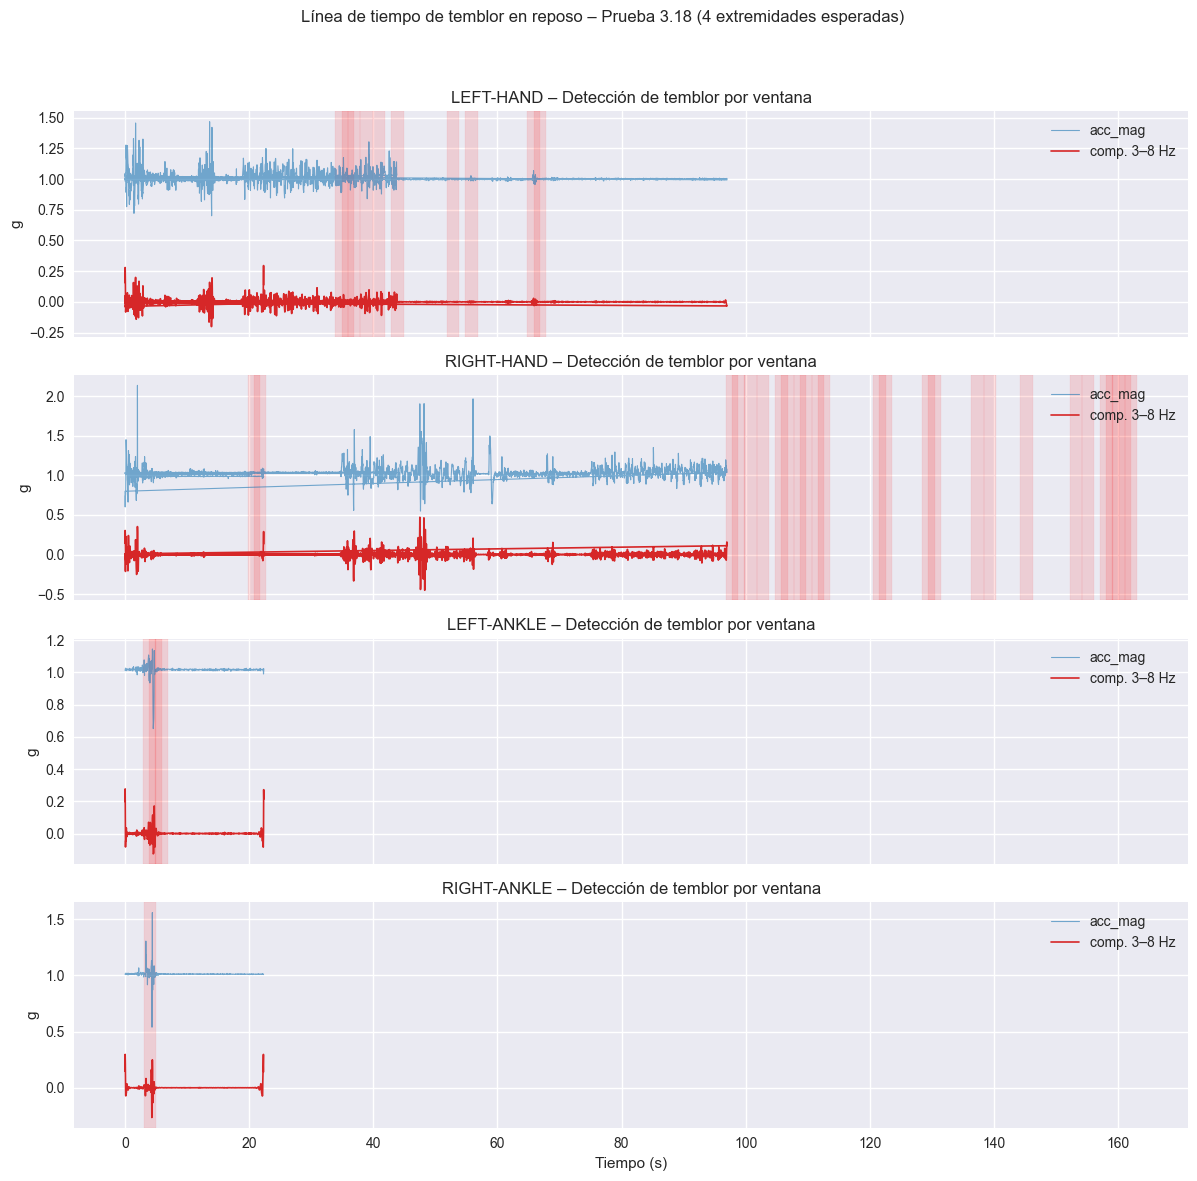

In [30]:
# Línea de tiempo de detección de temblor por ventana (extremidades esperadas)
if _USE_MPL and analysis_devices:
    fig, axes = plt.subplots(nrows=len(analysis_devices), ncols=1, figsize=(12, 3 * len(analysis_devices)), sharex=True)
    if len(analysis_devices) == 1:
        axes = [axes]

    for ax, dev in zip(axes, analysis_devices):
        sub = df_win[df_win['deviceId'] == dev]
        if sub.empty:
            ax.set_title(f'{dev} – Sin datos en este dataset')
            ax.text(0.5, 0.5, 'IMU faltante', transform=ax.transAxes, ha='center', va='center', color='gray')
            ax.set_ylabel('g')
            continue

        fs = fs_map.get(dev, float('nan'))
        if not np.isfinite(fs) or fs <= 0:
            ax.set_title(f'{dev} – Frecuencia de muestreo inválida')
            ax.text(0.5, 0.5, 'No analizable', transform=ax.transAxes, ha='center', va='center', color='gray')
            ax.set_ylabel('g')
            continue

        t = sub['t'].to_numpy()
        acc = sub['acc_mag'].to_numpy()
        acc_trem = simple_bandpass(acc, fs, 3, 8)

        ax.plot(t, acc, color='#1f77b4', lw=0.8, alpha=0.6, label='acc_mag')
        ax.plot(t, acc_trem, color='#d62728', lw=1.2, label='comp. 3–8 Hz')

        # Sombrear ventanas con temblor detectado (criterio validado en acc)
        win_sec = 2.0
        overlap = 0.5
        win_samp = int(fs * win_sec)
        step_samp = int(win_samp * (1 - overlap))
        idx = 0
        t_start_sig = float(t[0])

        while idx + win_samp <= len(acc):
            chunk = acc[idx:idx + win_samp] - np.mean(acc[idx:idx + win_samp])
            fq, Pxx = welch_psd(chunk, fs=fs, nperseg=min(512, max(64, win_samp // 2)))
            bm = (fq >= 3) & (fq <= 8)
            am = (fq >= 0.5) & (fq <= 15)
            bp2 = trapz_power(fq[bm], Pxx[bm])
            tp2 = trapz_power(fq[am], Pxx[am])
            r2 = bp2 / tp2 if tp2 > 0 else 0.0
            y2 = simple_bandpass(chunk, fs, 3, 8)
            rms2 = float(np.sqrt(np.mean(y2**2))) if y2.size else 0.0
            if r2 >= 0.3 and rms2 >= 0.02:
                t0 = t_start_sig + idx / fs
                t1 = t0 + win_sec
                ax.axvspan(t0, t1, color='red', alpha=0.12)
            idx += step_samp

        ax.set_title(f'{dev} – Detección de temblor por ventana')
        ax.set_ylabel('g')
        ax.legend(loc='upper right')

    axes[-1].set_xlabel('Tiempo (s)')
    fig.suptitle('Línea de tiempo de temblor en reposo – Prueba 3.18 (4 extremidades esperadas)')
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
else:
    print('No hay backend matplotlib o no se definieron IMUs de extremidades.')

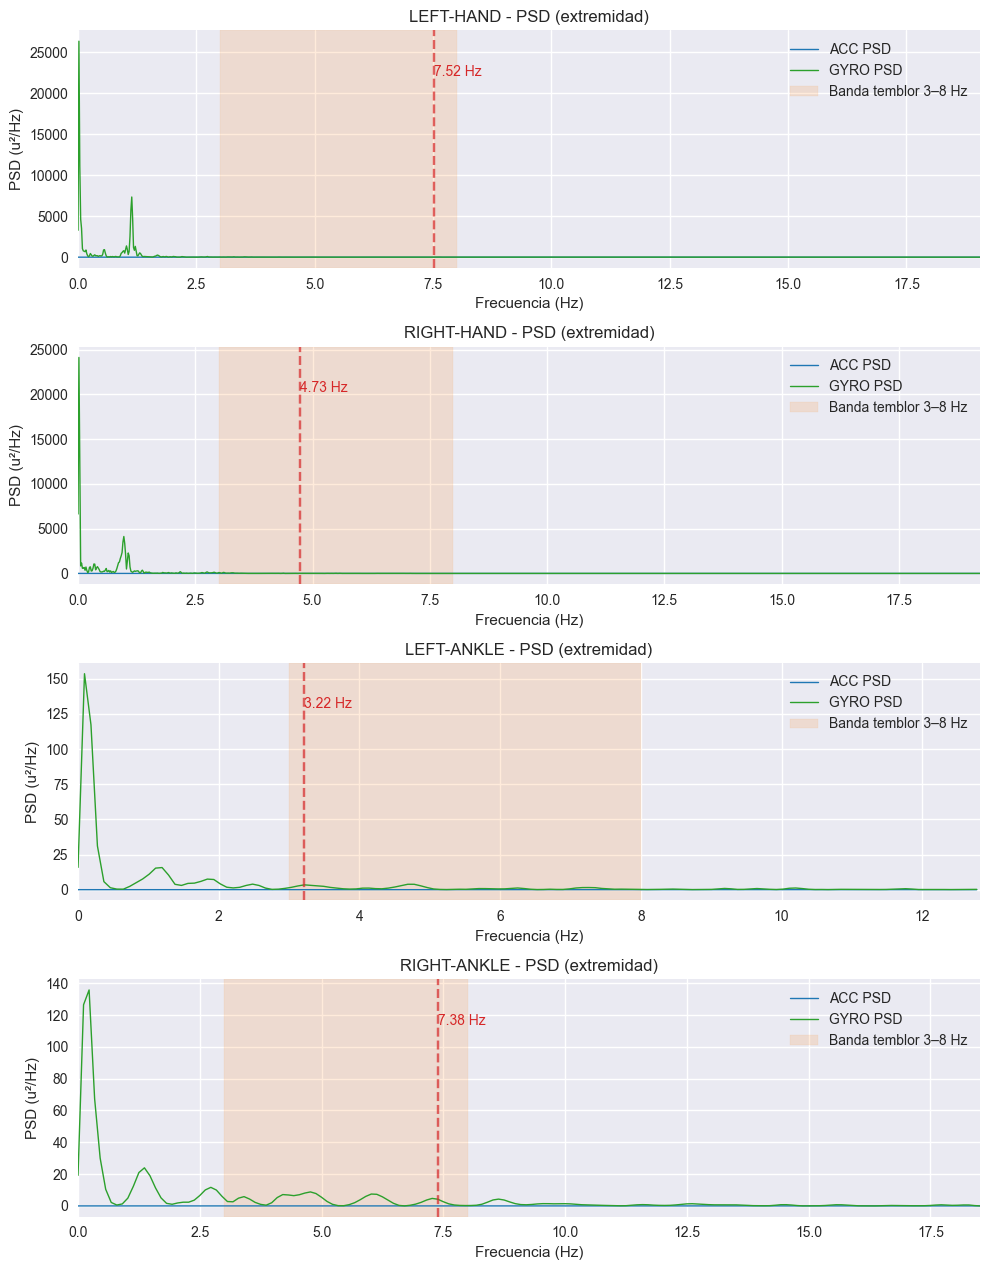

In [31]:
# PSD de extremidades con banda 3–8 Hz
if _USE_MPL and analysis_devices:
    n = len(analysis_devices)
    fig, axes = plt.subplots(nrows=n, ncols=1, figsize=(10, 3.2 * n), sharex=False)
    axes = np.atleast_1d(axes).ravel()

    for i, dev in enumerate(analysis_devices):
        ax = axes[i]
        sub = df_win[df_win['deviceId'] == dev]
        fs = fs_map.get(dev, float('nan'))

        if sub.empty:
            ax.set_title(f'{dev} - Sin datos en este dataset')
            ax.text(0.5, 0.5, 'IMU faltante', transform=ax.transAxes, ha='center', va='center', color='gray')
            ax.set_xlabel('Frecuencia (Hz)')
            ax.set_ylabel('PSD (u²/Hz)')
            continue

        if not np.isfinite(fs) or fs <= 0:
            ax.set_title(f'{dev} - Frecuencia inválida')
            ax.text(0.5, 0.5, 'No analizable', transform=ax.transAxes, ha='center', va='center', color='gray')
            ax.set_xlabel('Frecuencia (Hz)')
            ax.set_ylabel('PSD (u²/Hz)')
            continue

        acc_raw = sub['acc_mag'].to_numpy()
        gyro_raw = sub['gyro_mag'].to_numpy()
        if len(acc_raw) < 16 or len(gyro_raw) < 16:
            ax.set_title(f'{dev} - Datos insuficientes para PSD')
            ax.text(0.5, 0.5, 'No analizable', transform=ax.transAxes, ha='center', va='center', color='gray')
            ax.set_xlabel('Frecuencia (Hz)')
            ax.set_ylabel('PSD (u²/Hz)')
            continue

        acc = acc_raw - np.mean(acc_raw)
        gyro = gyro_raw - np.mean(gyro_raw)

        f_acc, P_acc = welch_psd(acc, fs=fs, nperseg=min(2048, max(256, len(acc) // 2)))
        f_gyro, P_gyro = welch_psd(gyro, fs=fs, nperseg=min(2048, max(256, len(gyro) // 2)))

        ax.plot(f_acc, P_acc, color='#1f77b4', lw=1, label='ACC PSD')
        ax.plot(f_gyro, P_gyro, color='#2ca02c', lw=1, label='GYRO PSD')
        ax.axvspan(3.0, 8.0, color='#ff7f0e', alpha=0.15, label='Banda temblor 3–8 Hz')

        det = persist_df[
            (persist_df['device'] == dev)
            & (persist_df['signal'] == 'acc_mag')
            & (persist_df['data_status'] == 'available')
            & (persist_df['persistence_score'] > 0)
        ]
        if not det.empty:
            bmask = (f_acc >= 3) & (f_acc <= 8)
            if np.any(bmask) and P_acc[bmask].size > 0:
                pk_idx = np.argmax(P_acc[bmask])
                pk_f = f_acc[bmask][pk_idx]
                ax.axvline(pk_f, color='#d62728', linestyle='--', alpha=0.7)
                ymax = ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 1.0
                ax.text(pk_f, ymax * 0.8, f"{pk_f:.2f} Hz", color='#d62728')

        ax.set_xlim(0, min(20, fs / 2))
        ax.set_xlabel('Frecuencia (Hz)')
        ax.set_ylabel('PSD (u²/Hz)')
        ax.set_title(f'{dev} - PSD (extremidad)')
        ax.legend(loc='upper right')

    fig.tight_layout()
    plt.show()
else:
    print('No hay backend matplotlib o no se definieron IMUs de extremidades.')

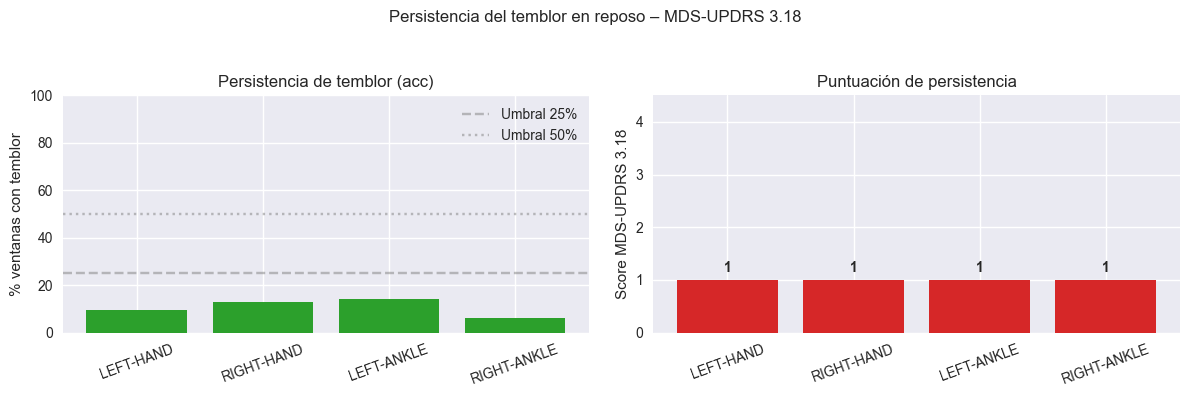

In [32]:
# Barras de persistencia de temblor (extremidades con datos disponibles)
if _USE_MPL and not persist_df.empty:
    acc_data = persist_df[(persist_df['signal'] == 'acc_mag') & (persist_df['data_status'] == 'available')].copy()
    if acc_data.empty:
        print('No hay resultados de acelerómetro disponibles para graficar persistencia.')
    else:
        display_order = [d for d in EXPECTED_318_EXTREMITIES if d in acc_data['device'].tolist()]
        acc_data = acc_data.set_index('device').reindex(display_order).reset_index()

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        colors = ['#d62728' if p > 25 else '#2ca02c' for p in acc_data['tremor_pct']]
        axes[0].bar(acc_data['device'], acc_data['tremor_pct'], color=colors)
        axes[0].axhline(25, color='gray', linestyle='--', alpha=0.5, label='Umbral 25%')
        axes[0].axhline(50, color='gray', linestyle=':', alpha=0.5, label='Umbral 50%')
        axes[0].set_ylabel('% ventanas con temblor')
        axes[0].set_title('Persistencia de temblor (acc)')
        axes[0].legend()
        axes[0].set_ylim(0, 100)
        axes[0].tick_params(axis='x', rotation=20)

        axes[1].bar(
            acc_data['device'],
            acc_data['persistence_score'],
            color=['#d62728' if s > 0 else '#2ca02c' for s in acc_data['persistence_score']],
        )
        axes[1].set_ylabel('Score MDS-UPDRS 3.18')
        axes[1].set_title('Puntuación de persistencia')
        axes[1].set_ylim(0, 4.5)
        axes[1].tick_params(axis='x', rotation=20)
        for _, row in acc_data.iterrows():
            axes[1].text(row['device'], row['persistence_score'] + 0.15, f"{int(row['persistence_score'])}", ha='center', fontweight='bold')

        fig.suptitle('Persistencia del temblor en reposo – MDS-UPDRS 3.18')
        fig.tight_layout(rect=[0, 0, 1, 0.93])
        plt.show()
else:
    print('No hay datos o matplotlib no disponible.')

## Interpretación para esta tarea

- Este cuaderno usa el enfoque final: **promedios de 3.15, 3.16 y 3.17** para estimar 3.18.
- Se calcula persistencia por prueba y luego se agrega por media/desviación estándar.
- La clasificación MDS-UPDRS 3.18 se obtiene del porcentaje promedio de temblor entre pruebas.
- Se evita depender de una sola toma, ganando robustez descriptiva.

In [33]:
# Resumen y puntuación MDS-UPDRS 3.18 (promedio 3.15–3.17)
print('=' * 72)
print('  RESUMEN – MDS-UPDRS 3.18: Persistencia del Temblor en Reposo')
print('  Paciente con Parkinson')
print('=' * 72)

if 'persist_df' in globals() and not persist_df.empty:
    display_cols = [
        'device', 'signal', 'data_status', 'n_windows', 'n_tremor_windows',
        'tremor_pct', 'tremor_pct_std', 'mean_ratio', 'mean_rms_tremor',
        'persistence_score', 'n_tests_used'
    ]
    display(persist_df[display_cols].round(4))

    available_scores = persist_df[
        (persist_df['data_status'] == 'available') & persist_df['persistence_score'].notna()
    ]['persistence_score']

    score_labels = {
        0: 'No hay temblor en reposo (0 % del tiempo)',
        1: 'Temblor presente <= 25 % del tiempo',
        2: 'Temblor presente 26–50 % del tiempo',
        3: 'Temblor presente 51–75 % del tiempo',
        4: 'Temblor presente > 75 % del tiempo',
    }

    if available_scores.empty:
        global_score = float('nan')
        print('\nPuntuación global estimada MDS-UPDRS 3.18: No evaluable (sin datos disponibles)')
    else:
        global_score = int(available_scores.max())
        print('\nPuntuación global estimada MDS-UPDRS 3.18:', global_score, '/ 4')
        print('Interpretación:', score_labels.get(global_score, 'N/A'))

    print('\nPruebas integradas en el promedio: 3.15, 3.16, 3.17')
    if 'persist_test_df' in globals() and not persist_test_df.empty:
        print('Resumen por prueba (promedio por IMU):')
        display(persist_test_df[['source_test', 'device', 'signal', 'tremor_pct', 'persistence_score']].round(4))

    acc_status = persist_df[persist_df['signal'] == 'acc_mag'][['device', 'data_status', 'persistence_score', 'tremor_pct', 'tremor_pct_std']].copy()
    if not acc_status.empty:
        print('\nEstado por extremidad (ACC):')
        display(acc_status.round(4))

    print('\nIMUs esperadas (protocolo 3.18):')
    print('  Extremidades:', EXPECTED_318_EXTREMITIES)
    print('  Referencia postural:', EXPECTED_318_REFERENCE)

    available_ext = [d for d in EXPECTED_318_EXTREMITIES if d in extremity_devices]
    missing_ext = [d for d in EXPECTED_318_EXTREMITIES if d not in available_ext]
    available_ref = [d for d in EXPECTED_318_REFERENCE if d in reference_devices]
    missing_ref = [d for d in EXPECTED_318_REFERENCE if d not in available_ref]

    print('\nCobertura real del dataset agregado:')
    print('  Extremidades disponibles:', available_ext if available_ext else 'Ninguna')
    print('  Extremidades faltantes:', missing_ext if missing_ext else 'Ninguna')
    print('  Referencia disponible:', available_ref if available_ref else 'Ninguna')
    print('  Referencia faltante:', missing_ref if missing_ref else 'Ninguna')

    if 'reference_df' in globals() and not reference_df.empty:
        print('\nReferencia postural (BASE-SPINE):')
        display(reference_df.round(4))

    print('\nNota metodológica final:')
    print('- 3.18 se estima por agregación de 3.15–3.17 (no por una sola toma puntual).')
    print('- Se reportan media y desviación estándar para robustez descriptiva.')
    print('- El score se clasifica con los rangos MDS-UPDRS a partir del porcentaje promedio de temblor.')
else:
    print('No hay resultados para mostrar.')

  RESUMEN – MDS-UPDRS 3.18: Persistencia del Temblor en Reposo
  Paciente con Parkinson


,device,signal,data_status,n_windows,n_tremor_windows,tremor_pct,tremor_pct_std,mean_ratio,mean_rms_tremor,persistence_score,n_tests_used
0,LEFT-HAND,acc_mag,available,31,3,9.7061,8.0005,0.3407,0.0102,1.0,3
1,LEFT-HAND,gyro_mag,available,31,8,27.5981,3.4485,0.3305,2.8923,2.0,3
2,RIGHT-HAND,acc_mag,available,34,5,12.7178,9.7000,0.3652,0.0122,1.0,3
3,RIGHT-HAND,gyro_mag,available,34,8,30.2211,8.6336,0.2961,3.1256,2.0,3
4,LEFT-ANKLE,acc_mag,available,21,3,14.2857,0.0000,0.3827,0.0079,1.0,1
5,LEFT-ANKLE,gyro_mag,available,21,7,33.3333,0.0000,0.2541,1.1893,2.0,1
6,RIGHT-ANKLE,acc_mag,available,16,1,6.2500,0.0000,0.2348,0.0104,1.0,1
7,RIGHT-ANKLE,gyro_mag,available,16,3,18.7500,0.0000,0.2013,1.8259,1.0,1



Puntuación global estimada MDS-UPDRS 3.18: 2 / 4
Interpretación: Temblor presente 26–50 % del tiempo

Pruebas integradas en el promedio: 3.15, 3.16, 3.17
Resumen por prueba (promedio por IMU):


,source_test,device,signal,tremor_pct,persistence_score
0,3.15,LEFT-HAND,acc_mag,0.0000,0
1,3.15,LEFT-HAND,gyro_mag,31.2500,2
2,3.15,RIGHT-HAND,acc_mag,0.0000,0
3,3.15,RIGHT-HAND,gyro_mag,29.4118,2
4,3.16,LEFT-HAND,acc_mag,19.5946,1
5,3.16,LEFT-HAND,gyro_mag,22.9730,1
6,3.16,RIGHT-HAND,acc_mag,14.6241,1
7,3.16,RIGHT-HAND,gyro_mag,20.0752,1
8,3.17,LEFT-ANKLE,acc_mag,14.2857,1
9,3.17,LEFT-ANKLE,gyro_mag,33.3333,2



Estado por extremidad (ACC):


,device,data_status,persistence_score,tremor_pct,tremor_pct_std
0,LEFT-HAND,available,1.0,9.7061,8.0005
2,RIGHT-HAND,available,1.0,12.7178,9.7000
4,LEFT-ANKLE,available,1.0,14.2857,0.0000
6,RIGHT-ANKLE,available,1.0,6.2500,0.0000



IMUs esperadas (protocolo 3.18):
  Extremidades: ['LEFT-HAND', 'RIGHT-HAND', 'LEFT-ANKLE', 'RIGHT-ANKLE']
  Referencia postural: ['BASE-SPINE']

Cobertura real del dataset agregado:
  Extremidades disponibles: ['LEFT-HAND', 'RIGHT-HAND', 'LEFT-ANKLE', 'RIGHT-ANKLE']
  Extremidades faltantes: Ninguna
  Referencia disponible: ['BASE-SPINE']
  Referencia faltante: Ninguna

Referencia postural (BASE-SPINE):


,source_test,device,fs,rms_acc_0p5_3hz,rms_gyro_0p5_3hz,data_status
0,3.15,BASE-SPINE,38.4615,0.0024,0.6577,available
1,3.16,BASE-SPINE,38.4615,0.0031,1.2288,available
2,3.17,BASE-SPINE,38.4615,0.0066,1.4118,available
3,PROMEDIO_3.15_3.17,BASE-SPINE,38.4615,0.0041,1.0994,available



Nota metodológica final:
- 3.18 se estima por agregación de 3.15–3.17 (no por una sola toma puntual).
- Se reportan media y desviación estándar para robustez descriptiva.
- El score se clasifica con los rangos MDS-UPDRS a partir del porcentaje promedio de temblor.
